In [4]:
# %% [markdown]
#
# 
# **Objective:** Analyze the harvested candlestick data to discover statistically significant thresholds for a valid "impulsive exit."
# **Data:** `SD_BaseExit_XAUUSDr_5.csv`
# **Method:** Exploratory Data Analysis (EDA), Distribution Analysis, and Success Rate Correlation.

# %% [markdown]
# ## 1. Setup & Data Ingestion (Corrected)
# Loading tab-delimited data

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data with TAB as delimiter
file_path = "SD_BaseExit_XAUUSDr_5.csv"
df = pd.read_csv(file_path, sep='\t')  # Tab-separated

print("✅ Data loaded successfully (tab-delimited).")
print(f"Dataset shape: {df.shape}")
print("\n🔍 Column names:")
print(list(df.columns))
print("\n📊 First 3 rows:")
print(df.head(3))

✅ Data loaded successfully (tab-delimited).
Dataset shape: (9663, 14)

🔍 Column names:
['Pattern', 'Symbol', 'Timeframe', 'Timestamp', 'Base_BodyPips', 'Exit_BodyPips', 'ExitToBaseRatio', 'ATR_Pips', 'Base_BodyATR', 'Exit_BodyATR', 'Base_Open', 'Base_Close', 'Exit_Open', 'Exit_Close']

📊 First 3 rows:
  Pattern   Symbol  Timeframe            Timestamp  Base_BodyPips  \
0  Demand  XAUUSDr          5  2026-01-12T06:45:00          194.0   
1  Demand  XAUUSDr          5  2026-01-12T06:40:00          226.0   
2  Supply  XAUUSDr          5  2026-01-12T06:30:00          104.0   

   Exit_BodyPips  ExitToBaseRatio  ATR_Pips  Base_BodyATR  Exit_BodyATR  \
0          155.0             0.80    311.64         0.545         0.497   
1          194.0             0.86    355.64         0.632         0.545   
2          477.0             4.59    365.79         0.273         1.304   

   Base_Open  Base_Close  Exit_Open  Exit_Close  
0    4566.03     4567.97    4567.96     4569.51  
1    4563.80     45

In [5]:
# %% [markdown]
# ## 2. Initial Data Inspection & Cleaning

# %%
print("📊 Dataset Info:")
print(df.info())
print("\n🧹 Checking for missing values:")
print(df.isnull().sum())

# Ensure numeric columns are correctly typed
numeric_cols = ['Base_BodyPips', 'Exit_BodyPips', 'ExitToBaseRatio', 'ATR_Pips', 'Base_BodyATR', 'Exit_BodyATR']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"⚠️ Warning: Column '{col}' not found in data")

# Remove any rows with missing critical data
df_clean = df.dropna(subset=numeric_cols).copy()
print(f"\n🧽 Data cleaned. Original: {df.shape}, Cleaned: {df_clean.shape}")

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9663 entries, 0 to 9662
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pattern          9663 non-null   object 
 1   Symbol           9663 non-null   object 
 2   Timeframe        9663 non-null   int64  
 3   Timestamp        9663 non-null   object 
 4   Base_BodyPips    9663 non-null   float64
 5   Exit_BodyPips    9663 non-null   float64
 6   ExitToBaseRatio  9663 non-null   float64
 7   ATR_Pips         9663 non-null   float64
 8   Base_BodyATR     9663 non-null   float64
 9   Exit_BodyATR     9663 non-null   float64
 10  Base_Open        9663 non-null   float64
 11  Base_Close       9663 non-null   float64
 12  Exit_Open        9663 non-null   float64
 13  Exit_Close       9663 non-null   float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.0+ MB
None

🧹 Checking for missing values:
Pattern            0
Symbol             0

🧮 Descriptive Statistics of Key Metrics:
       Base_BodyPips  Exit_BodyPips  ExitToBaseRatio  ATR_Pips  Base_BodyATR  \
count        9663.00        9663.00          9663.00   9663.00       9663.00   
mean          237.15         247.71             4.13    473.72          0.62   
std           253.53         268.18            17.92    230.17          0.82   
min             1.00           1.00             0.00     99.50          0.00   
25%            74.00          75.00             0.42    316.64          0.16   
50%           168.00         173.00             1.04    421.00          0.38   
75%           314.00         325.50             2.55    568.36          0.78   
max          3441.00        3441.00           770.00   2156.36         22.79   

       Exit_BodyATR  
count       9663.00  
mean           0.64  
std            0.85  
min            0.00  
25%            0.16  
50%            0.39  
75%            0.81  
max           22.79  

📈 Pattern Type Distribution:
Pattern
De

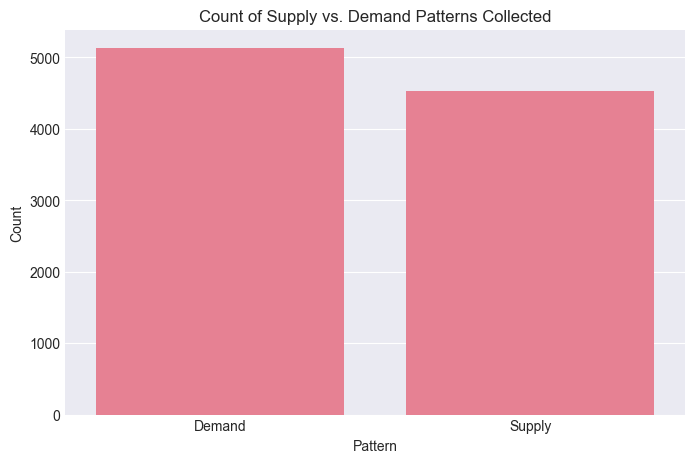

In [8]:
# %% [markdown]
# ## 3. Exploratory Data Analysis (EDA)

# %%
print("🧮 Descriptive Statistics of Key Metrics:")
print(df_clean[numeric_cols].describe().round(2))

# Pattern Distribution
print(f"\n📈 Pattern Type Distribution:")
if 'Pattern' in df_clean.columns:
    pattern_counts = df_clean['Pattern'].value_counts()
    print(pattern_counts)
    
    # Simple Visualization: Pattern Count
    plt.figure(figsize=(8,5))
    sns.barplot(x=pattern_counts.index, y=pattern_counts.values)
    plt.title('Count of Supply vs. Demand Patterns Collected')
    plt.ylabel('Count')
    plt.show()
else:
    print("⚠️ 'Pattern' column not found")



In [11]:
# Add this after creating df_clean, BEFORE the clustering cell
# Filter to only look at patterns where exit was at least 1.5x the base
df_strong = df_clean[df_clean['ExitToBaseRatio'] > 1.5].copy()
print(f"Analyzing strong candidates: {df_strong.shape[0]} patterns (>{df_clean.shape[0]} total)")

Analyzing strong candidates: 3725 patterns (>9663 total)


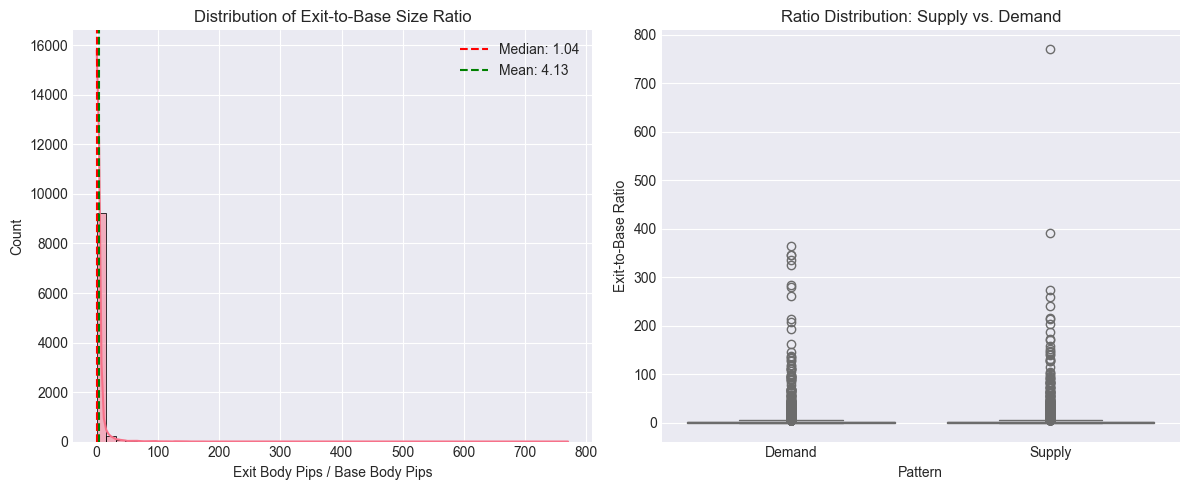

📐 Key Percentiles for ExitToBaseRatio:
  5th percentile: 0.08
  25th percentile: 0.42
  50th percentile: 1.04
  75th percentile: 2.55
  90th percentile: 6.67
  95th percentile: 13.41
  99th percentile: 61.57


In [12]:
# %% [markdown]
# ## 4. Core Analysis: Distribution of Exit-to-Base Ratio

# %%
if 'ExitToBaseRatio' in df_clean.columns:
    plt.figure(figsize=(12, 5))
    
    # Histogram with KDE
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_clean, x='ExitToBaseRatio', bins=50, kde=True)
    plt.axvline(x=df_clean['ExitToBaseRatio'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ExitToBaseRatio"].median():.2f}')
    plt.axvline(x=df_clean['ExitToBaseRatio'].mean(), color='green', linestyle='--', 
                label=f'Mean: {df_clean["ExitToBaseRatio"].mean():.2f}')
    plt.title('Distribution of Exit-to-Base Size Ratio')
    plt.xlabel('Exit Body Pips / Base Body Pips')
    plt.legend()
    
    # Box plot by Pattern type
    if 'Pattern' in df_clean.columns:
        plt.subplot(1, 2, 2)
        sns.boxplot(data=df_clean, x='Pattern', y='ExitToBaseRatio')
        plt.title('Ratio Distribution: Supply vs. Demand')
        plt.ylabel('Exit-to-Base Ratio')
    
    plt.tight_layout()
    plt.show()
    
    # Critical Percentile Analysis
    print("📐 Key Percentiles for ExitToBaseRatio:")
    percentiles = [5, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        value = df_clean['ExitToBaseRatio'].quantile(p/100)
        print(f"  {p}th percentile: {value:.2f}")
else:
    print("⚠️ 'ExitToBaseRatio' column not found")

<Axes: xlabel='Base_BodyATR', ylabel='ExitToBaseRatio'>

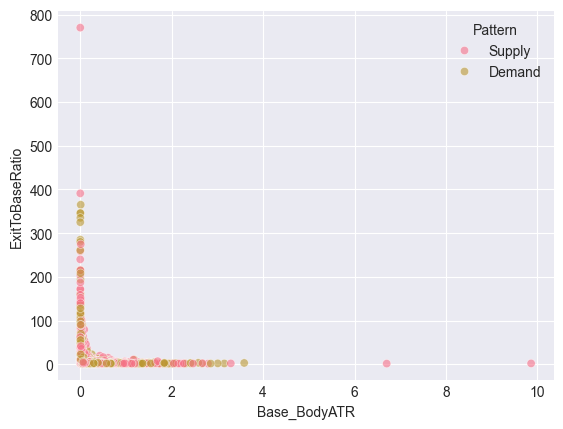

In [13]:
# Use the filtered dataframe for strong candidates only
df_to_plot = df_strong  # Instead of df_clean

# Then proceed with your scatter plot code, using df_to_plot
sns.scatterplot(data=df_to_plot, x='Base_BodyATR', y='ExitToBaseRatio', hue='Pattern', alpha=0.6)

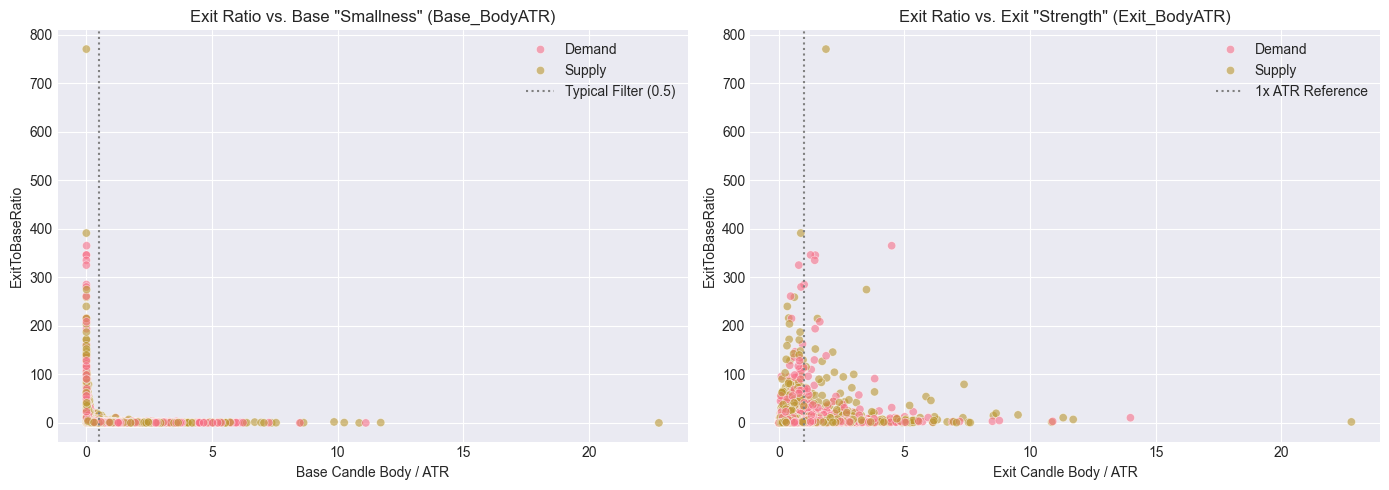

In [7]:
# %% [markdown]
# ## 5. Contextualizing Size: The Role of Volatility (ATR)

# %%
if all(col in df_clean.columns for col in ['Base_BodyATR', 'Exit_BodyATR', 'ExitToBaseRatio', 'Pattern']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Base Body vs. ATR
    sns.scatterplot(data=df_clean, x='Base_BodyATR', y='ExitToBaseRatio', hue='Pattern', alpha=0.6, ax=axes[0])
    axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Typical Filter (0.5)')
    axes[0].set_title('Exit Ratio vs. Base "Smallness" (Base_BodyATR)')
    axes[0].set_xlabel('Base Candle Body / ATR')
    axes[0].legend()
    
    # Exit Body vs. ATR
    sns.scatterplot(data=df_clean, x='Exit_BodyATR', y='ExitToBaseRatio', hue='Pattern', alpha=0.6, ax=axes[1])
    axes[1].axvline(x=1.0, color='gray', linestyle=':', label='1x ATR Reference')
    axes[1].set_title('Exit Ratio vs. Exit "Strength" (Exit_BodyATR)')
    axes[1].set_xlabel('Exit Candle Body / ATR')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Missing required columns for ATR analysis")

Preparing features for clustering...
Features shape: (3725, 2)
Features scaled (standardized).

Running Elbow Method to suggest optimal K...


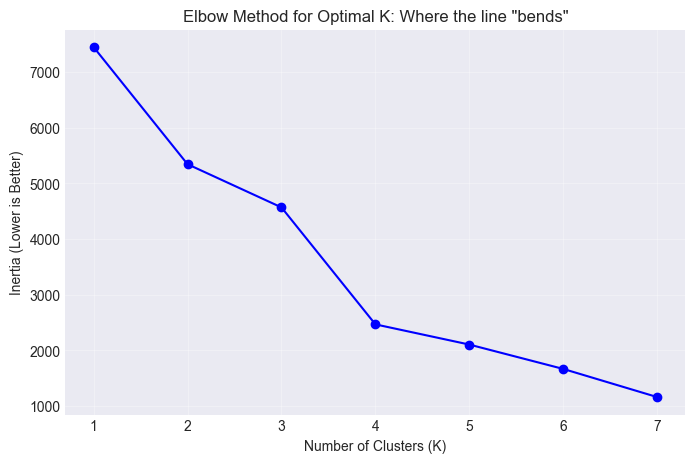

Inertia values: ['7450', '5344', '4568', '2465', '2102', '1664', '1158']
Look for a 'kink' or elbow in the plot above. Often K=2 or K=3 works well.

Applying K-Means clustering with K = 3...
Clustering complete. Cluster labels added to 'df_strong'.

Visualizing clusters...


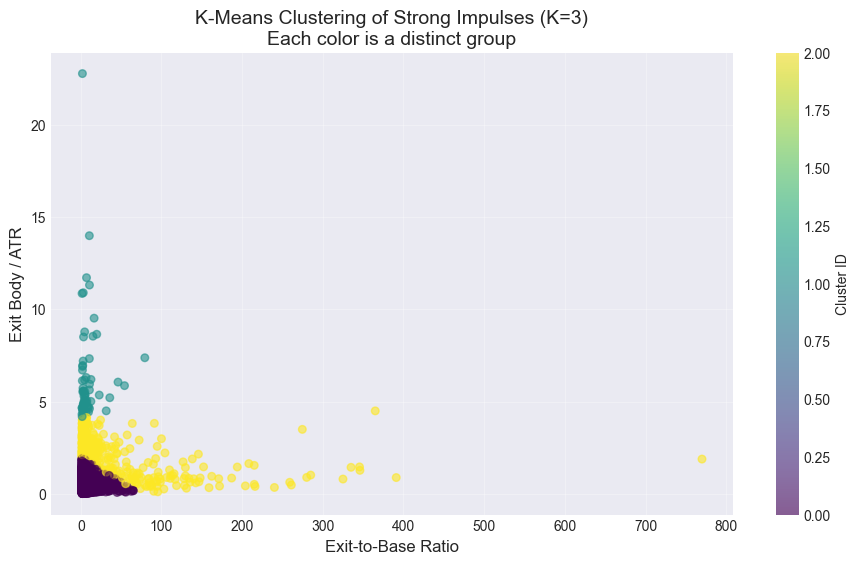

CLUSTER PROFILE ANALYSIS

📊 1. Number of patterns per cluster:
   Cluster 0: 3153 patterns (84.6% of strong candidates)
   Cluster 1:   62 patterns (1.7% of strong candidates)
   Cluster 2:  510 patterns (13.7% of strong candidates)

📈 2. Cluster Centers (MEAN values):
         ExitToBaseRatio  Exit_BodyATR  Base_BodyATR
Cluster                                             
0                  5.845         0.670         0.216
1                  9.649         6.391         1.541
2                 34.023         2.264         0.566

📐 3. Key PERCENTILES for ExitToBaseRatio in each cluster:

   Cluster 0:
     25th percentile: 2.11
     50th percentile: 3.21
     75th percentile: 6.21
     90th percentile: 12.73

   Cluster 1:
     25th percentile: 2.99
     50th percentile: 4.80
     75th percentile: 10.63
     90th percentile: 19.45

   Cluster 2:
     25th percentile: 2.75
     50th percentile: 5.75
     75th percentile: 32.23
     90th percentile: 98.36

🧩 4. Pattern Type (Supply/Deman

In [14]:
# %% [markdown]
# ## 6. Statistical Clustering: Finding Natural "Impulsive Exit" Groups
# **Objective:** Use K-Means clustering to see if our strong candidates (`df_strong`) naturally group into categories like "Moderate" and "Strong" impulses based on their size ratio and volatility-adjusted strength.

# %%
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- Step 1: Prepare Features for Clustering ---
# We will cluster based on TWO dimensions:
# 1. ExitToBaseRatio (How much bigger is the exit?)
# 2. Exit_BodyATR (How significant is the exit in current market noise?)
print("Preparing features for clustering...")
cluster_features = df_strong[['ExitToBaseRatio', 'Exit_BodyATR']].copy()

# Check for any missing values (should be none after our cleaning)
print(f"Features shape: {cluster_features.shape}")

# Standardize the features (critical for K-Means)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(cluster_features)
print("Features scaled (standardized).\n")

# --- Step 2: The Elbow Method (Optional but Recommended) ---
# Helps suggest a reasonable number of clusters (K).
print("Running Elbow Method to suggest optimal K...")
inertias = []
K_range = range(1, 8)  # Test from 1 to 7 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')  # n_init='auto' for newer scikit-learn
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)  # Inertia = sum of squared distances to cluster center

# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Lower is Better)')
plt.title('Elbow Method for Optimal K: Where the line "bends"')
plt.grid(True, alpha=0.3)
plt.show()

print("Inertia values:", [f"{i:.0f}" for i in inertias])
print("Look for a 'kink' or elbow in the plot above. Often K=2 or K=3 works well.\n")

# --- Step 3: Apply K-Means Clustering ---
# YOU NEED TO CHOOSE K based on the elbow plot and your research goal.
# For distinguishing "Strong" vs "Very Strong" impulses, start with K=2 or 3.
chosen_k = 3  # <-- CHANGE THIS based on the elbow plot. Try 2 or 3.
print(f"Applying K-Means clustering with K = {chosen_k}...")

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(features_scaled)

# Add the cluster labels back to our main dataframe
df_strong['Cluster'] = cluster_labels
print(f"Clustering complete. Cluster labels added to 'df_strong'.\n")

# --- Step 4: Visualize the Clusters ---
print("Visualizing clusters...")
plt.figure(figsize=(11, 6))

# Create a scatter plot, coloring points by their assigned cluster
scatter = plt.scatter(df_strong['ExitToBaseRatio'], 
                      df_strong['Exit_BodyATR'],
                      c=df_strong['Cluster'], 
                      cmap='viridis', 
                      alpha=0.6,
                      s=30)  # s is point size

plt.xlabel('Exit-to-Base Ratio', fontsize=12)
plt.ylabel('Exit Body / ATR', fontsize=12)
plt.title(f'K-Means Clustering of Strong Impulses (K={chosen_k})\nEach color is a distinct group', fontsize=14)

# Add a colorbar and grid
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

# --- Step 5: Analyze and Profile Each Cluster ---
print("="*60)
print("CLUSTER PROFILE ANALYSIS")
print("="*60)

# 5.1 Basic Counts
print("\n📊 1. Number of patterns per cluster:")
cluster_counts = df_strong['Cluster'].value_counts().sort_index()
for clus_id, count in cluster_counts.items():
    percentage = (count / len(df_strong)) * 100
    print(f"   Cluster {clus_id}: {count:4d} patterns ({percentage:.1f}% of strong candidates)")

# 5.2 Mean (Center) of each cluster
print("\n📈 2. Cluster Centers (MEAN values):")
# Get the original feature means for each cluster
cluster_profile = df_strong.groupby('Cluster')[['ExitToBaseRatio', 'Exit_BodyATR', 'Base_BodyATR']].mean().round(3)
print(cluster_profile)

# 5.3 Key Percentiles within each cluster (more robust than mean)
print("\n📐 3. Key PERCENTILES for ExitToBaseRatio in each cluster:")
for clus_id in range(chosen_k):
    cluster_data = df_strong[df_strong['Cluster'] == clus_id]
    print(f"\n   Cluster {clus_id}:")
    for p in [25, 50, 75, 90]:  # 25th, Median (50th), 75th, 90th percentiles
        value = cluster_data['ExitToBaseRatio'].quantile(p/100)
        print(f"     {p}th percentile: {value:.2f}")

# 5.4 Pattern Type distribution within clusters
if 'Pattern' in df_strong.columns:
    print("\n🧩 4. Pattern Type (Supply/Demand) mix per cluster:")
    pattern_mix = pd.crosstab(df_strong['Cluster'], df_strong['Pattern'], normalize='index') * 100
    print(pattern_mix.round(1).astype(str) + ' %')

print("\n" + "="*60)
print("ANALYSIS COMPLETE")